In [251]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [252]:
data=pd.read_csv('Customers.csv')

In [253]:
data.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [254]:
data.dropna(inplace=True)

In [255]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,0
Work Experience,0
Family Size,0


In [256]:
data.drop_duplicates(inplace=True)

In [257]:
q1=data['Age'].quantile(0.25)
q3=data['Age'].quantile(0.75)
IQR=q3-q1
upper=q3+1.5*IQR
lower=q1-1.5*IQR
data=data[(data['Age']<upper) & (data['Age']>lower)]

In [258]:
quant=[]
cat=[]
for i in data.columns:
    if data[i].nunique()>10:
        quant.append(i)
    else:
        cat.append(i)

In [259]:
cat

['Gender', 'Profession', 'Family Size']

In [260]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              1965 non-null   int64 
 1   Gender                  1965 non-null   object
 2   Age                     1965 non-null   int64 
 3   Annual Income ($)       1965 non-null   int64 
 4   Spending Score (1-100)  1965 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         1965 non-null   int64 
 7   Family Size             1965 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 138.2+ KB


In [261]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat:
    data[i]=le.fit_transform(data[i])

In [262]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              1965 non-null   int64
 1   Gender                  1965 non-null   int64
 2   Age                     1965 non-null   int64
 3   Annual Income ($)       1965 non-null   int64
 4   Spending Score (1-100)  1965 non-null   int64
 5   Profession              1965 non-null   int64
 6   Work Experience         1965 non-null   int64
 7   Family Size             1965 non-null   int64
dtypes: int64(8)
memory usage: 138.2 KB


In [263]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data[quant]=scaler.fit_transform(data[quant])

<Axes: >

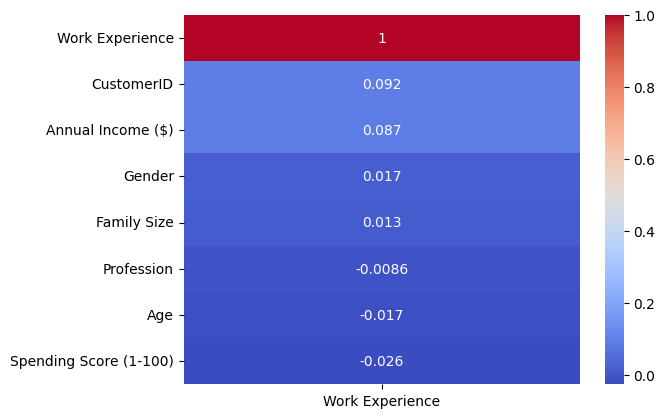

In [264]:
#coorelation

import seaborn as sns

corr=data.corr()

labeled_corr=corr[['Work Experience']].sort_values(by='Work Experience',ascending=False)

sns.heatmap(labeled_corr,annot=True,cmap='coolwarm')



In [265]:
data.drop('Family Size',axis=1,inplace=True)

In [266]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1965 non-null   float64
 1   Gender                  1965 non-null   int64  
 2   Age                     1965 non-null   float64
 3   Annual Income ($)       1965 non-null   float64
 4   Spending Score (1-100)  1965 non-null   float64
 5   Profession              1965 non-null   int64  
 6   Work Experience         1965 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 122.8 KB


In [267]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1965 non-null   float64
 1   Gender                  1965 non-null   int64  
 2   Age                     1965 non-null   float64
 3   Annual Income ($)       1965 non-null   float64
 4   Spending Score (1-100)  1965 non-null   float64
 5   Profession              1965 non-null   int64  
 6   Work Experience         1965 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 122.8 KB


In [268]:
data.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience
0,0.000000,1,0.191919,0.078958,0.39,5,0.058824
1,0.000500,1,0.212121,0.184236,0.81,2,0.176471
2,0.001001,0,0.202020,0.452694,0.06,2,0.058824
3,0.001501,0,0.232323,0.310569,0.77,7,0.000000
4,0.002001,0,0.313131,0.200027,0.40,3,0.117647


In [269]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

new_data = pca.fit_transform(data)

In [270]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, n_init=1000)

kmeans.fit(new_data)

print("Inertia:", kmeans.inertia_)

labels = kmeans.predict(new_data)

silhouette_avg = silhouette_score(new_data, labels)

Inertia: 1752.0043162841553


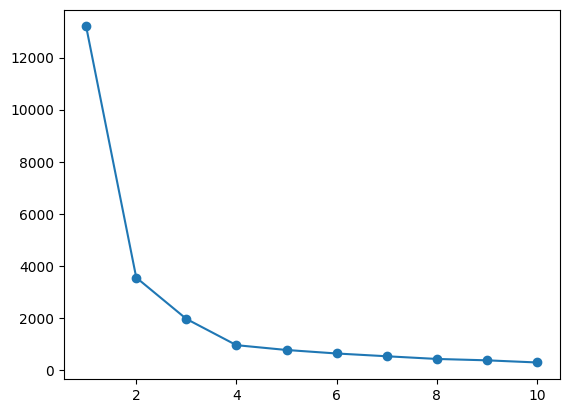

In [271]:
inertia_values = []
K_range = range(1,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(new_data)
    inertia_values.append(kmeans.inertia_)
plt.plot(K_range,inertia_values,marker='o')

In [272]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
hc = AgglomerativeClustering(n_clusters=2)
labels = hc.fit_predict(new_data)
silhouette_avg = silhouette_score(new_data, labels)
silhouette_avg

np.float64(0.6249391150464195)